# TCS Stock Data — EDA & Preprocessing

Follows the standard preprocessing checklist:
understand data -> missing values -> duplicates -> data types -> outliers -> visualize

No encoding/scaling step is required here — there are no categorical columns, and tree-based models don't need scaling. Scaling code is included near the end, commented out, in case you use Linear Regression / SVR / a Neural Network instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
%matplotlib inline

## 1. Understand the Data

In [2]:
df = pd.read_csv('TCS_stock_cleaned.csv')
print('Shape:', df.shape)
df.info()

Shape: (5873, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5873 entries, 0 to 5872
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             5873 non-null   object 
 1   Adj Close        5873 non-null   float64
 2   Close            5873 non-null   float64
 3   High             5873 non-null   float64
 4   Low              5873 non-null   float64
 5   Open             5873 non-null   float64
 6   Volume           5873 non-null   int64  
 7   Predicted_Close  5873 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 367.2+ KB


In [3]:
# # 1. Is Predicted_Close actually "tomorrow's close"?
# print(df[['Date', 'Close', 'Predicted_Close']].head(10))

# # 2. How correlated is today's Close with tomorrow's Predicted_Close?
# # For real stock data this should be ~0.99 — if it's low, the target column
# # isn't what we think it is.
# print("Correlation:", df['Close'].corr(df['Predicted_Close']))

# # 3. Confirm your actual metrics right now
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np
# print("R2:", r2_score(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("Test set price range:", y_test.min(), "-", y_test.max())
# print("Train set price range:", y_train.min(), "-", y_train.max())

In [4]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Predicted_Close
0,2002-08-12,25.828407,39.700001,40.000000,38.724998,38.724998,212976,39.162498
1,2002-08-13,25.478718,39.162498,40.387501,38.875000,39.750000,153576,36.462502
2,2002-08-14,23.722118,36.462502,39.250000,35.724998,39.250000,822776,36.462502
3,2002-08-15,23.722118,36.462502,36.462502,36.462502,36.462502,0,36.375000
4,2002-08-16,23.665195,36.375000,38.000000,35.750000,36.275002,811856,35.474998


In [5]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume,Predicted_Close
count,5873.000000,5873.000000,5873.000000,5873.000000,5873.000000,5.873000e+03,5873.000000
mean,1210.230140,1394.168384,1408.788685,1380.119414,1394.903159,3.157912e+06,1394.582636
std,1218.095590,1290.775462,1302.399322,1279.816035,1291.383085,3.033987e+06,1290.731093
min,23.079664,35.474998,36.450001,32.474998,32.474998,0.000000e+00,35.474998
25%,170.715881,254.425003,258.750000,250.750000,255.000000,1.659328e+06,254.449997
50%,841.392395,1103.074951,1114.500000,1088.449951,1103.000000,2.496264e+06,1103.474976
75%,1892.184937,2215.300049,2243.899902,2192.600098,2216.000000,3.864020e+06,2215.399902
max,4311.585449,4553.750000,4592.250000,4512.000000,4576.000000,8.806715e+07,4553.750000


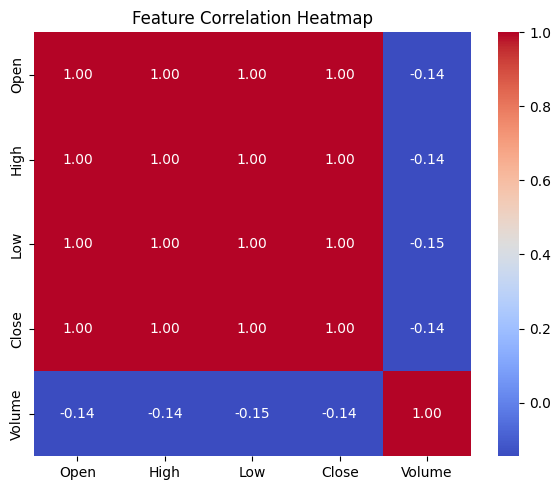

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 2. Handle Missing Values

Only the last row has a missing `Predicted_Close` (there's no "tomorrow" for the most recent date). Since it's just 1 row out of ~5,874, we drop it rather than fill it — filling a **target** column with mean/median would inject fake data into your label.

In [7]:
df.isnull().sum()

Date               0
Adj Close          0
Close              0
High               0
Low                0
Open               0
Volume             0
Predicted_Close    0
dtype: int64

In [8]:
df = df.dropna(subset=['Predicted_Close'])
print('Shape after dropping missing target row:', df.shape)

Shape after dropping missing target row: (5873, 8)


## 3. Remove Duplicates

In [9]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


## 4. Fix Data Types

`Date` is currently text (e.g. `12-08-2002`) — convert to a real datetime, then sort chronologically. Sorting is **critical** for time-series data so later train/test splits stay in correct time order.

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Predicted_Close
0,2002-08-12,25.828407,39.700001,40.000000,38.724998,38.724998,212976,39.162498
1,2002-08-13,25.478718,39.162498,40.387501,38.875000,39.750000,153576,36.462502
2,2002-08-14,23.722118,36.462502,39.250000,35.724998,39.250000,822776,36.462502
3,2002-08-15,23.722118,36.462502,36.462502,36.462502,36.462502,0,36.375000
4,2002-08-16,23.665195,36.375000,38.000000,35.750000,36.275002,811856,35.474998


## 5. Handle Outliers

Check `Volume = 0` rows (unusual for an actively traded stock — likely data glitches). We keep these rows since `Open/High/Low/Close` are still valid for them.

In [11]:
zero_vol = (df['Volume'] == 0).sum()
print(f'Rows with Volume = 0: {zero_vol}')

Rows with Volume = 0: 312


IQR check on `Close` — for information only, **not applied**. Stock prices legitimately grew from ~₹35 to ~₹4,550 over 24 years, so blanket IQR-based removal would delete real, valid data. Don't apply generic outlier removal to a trending time series.

In [12]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
flagged = df[(df['Close'] < lower) | (df['Close'] > upper)]
print(f"Rows IQR would flag as 'outliers': {len(flagged)} (not removed — see note above)")

Rows IQR would flag as 'outliers': 0 (not removed — see note above)


## 6. Visualize

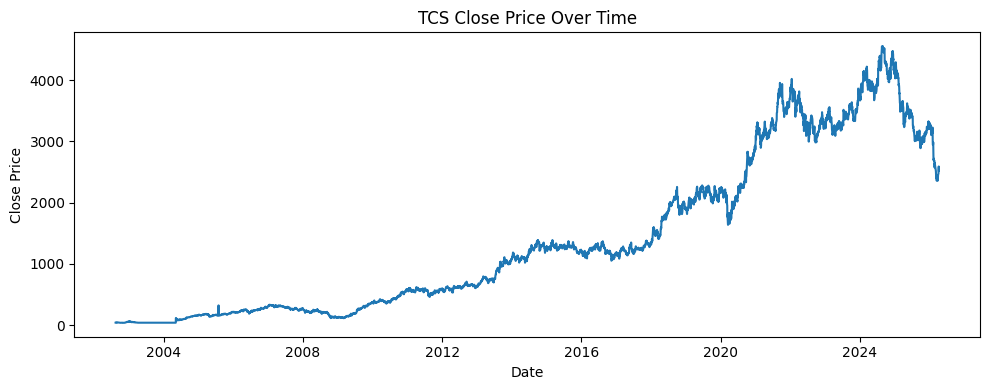

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'])
plt.title('TCS Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.tight_layout()
plt.show()

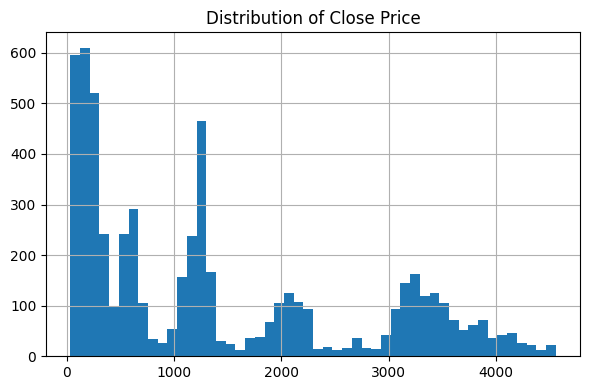

In [14]:
plt.figure(figsize=(6, 4))
df['Close'].hist(bins=50)
plt.title('Distribution of Close Price')
plt.tight_layout()
plt.show()

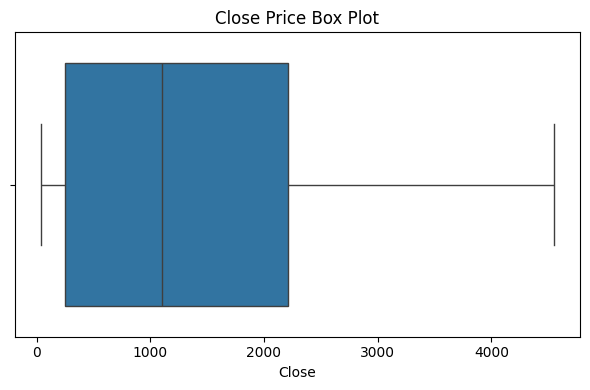

In [15]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Close'])
plt.title('Close Price Box Plot')
plt.tight_layout()
plt.show()

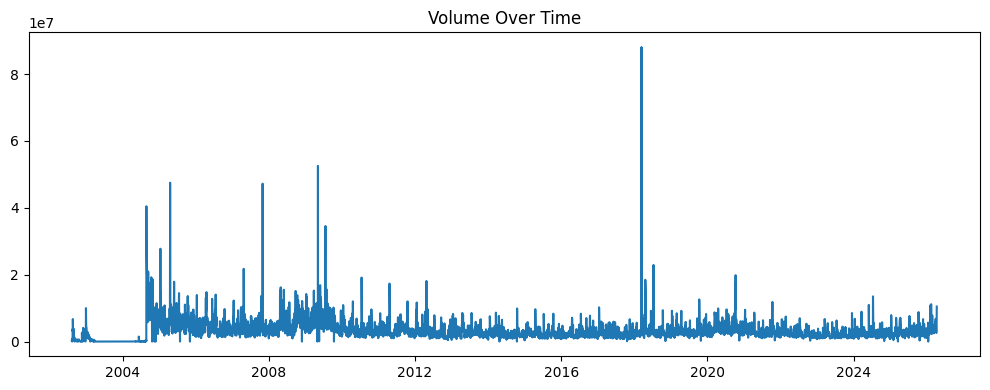

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Volume'])
plt.title('Volume Over Time')
plt.tight_layout()
plt.show()

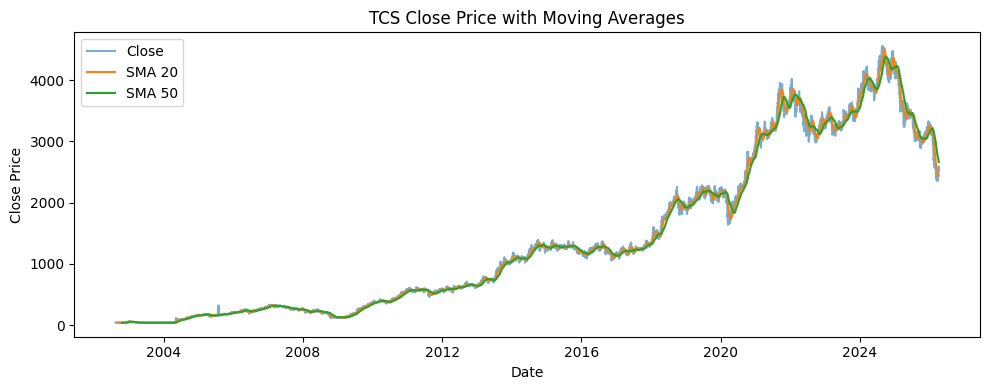

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], label='Close', alpha=0.6)
plt.plot(df['Date'], df['Close'].rolling(20).mean(), label='SMA 20')
plt.plot(df['Date'], df['Close'].rolling(50).mean(), label='SMA 50')
plt.title('TCS Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

## Final Clean Dataset

In [18]:
print('Final shape after preprocessing:', df.shape)
df.to_csv('TCS_stock_cleaned.csv', index=False)

Final shape after preprocessing: (5873, 8)


## Linear Regression

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv('TCS_stock_cleaned.csv')
X = df[['Open', 'High', 'Low', 'Close']]
y = df['Predicted_Close']

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# --- Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Coefficients (Open, High, Low, Close):', model.coef_)
print('Intercept:', model.intercept_)

y_pred = model.predict(X_test_scaled)

# --- Evaluation (was missing before — you can't know if the model is good without this) ---
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
print(f'R2:   {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')

Coefficients (Open, High, Low, Close): [-37.72714864  41.30578127  86.20807502 699.83900327]
Intercept: 862.6039649254174
R2:   0.9872
RMSE: 47.32
MAE:  34.11


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  ₹34.11
RMSE: ₹47.32
R²:   0.9872


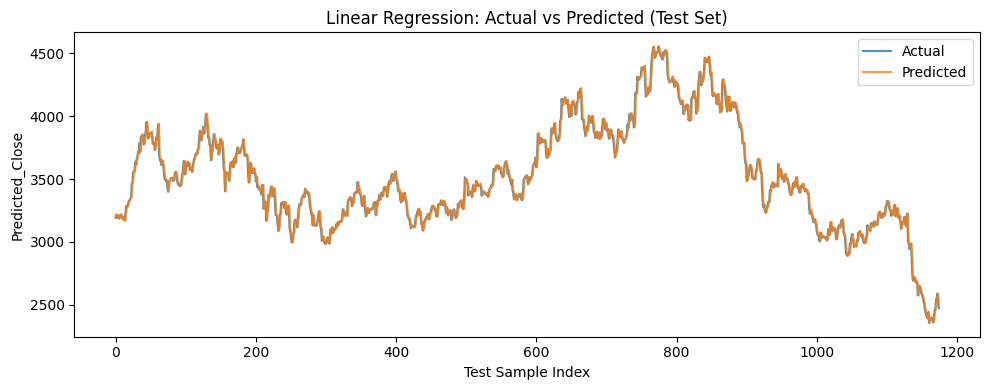

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual', alpha=0.8)
plt.plot(y_pred, label='Predicted', alpha=0.8)
plt.title('Linear Regression: Actual vs Predicted (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Predicted_Close')
plt.legend()
plt.tight_layout()
plt.show()

### Gradient Descent (from-scratch, for comparison/learning only)

**Note:** this from-scratch model is not the one saved for the app below — `LinearRegression` from the cell above is. This section trains on a proper train/test split (the earlier version trained and evaluated on the exact same data, which isn't a real generalization check) and is kept only to compare against sklearn's result.

In [22]:
X_gd = df[['Open', 'High', 'Low', 'Close']].values.astype(float)
y_gd = df['Predicted_Close'].values.astype(float)

split = int(len(df) * 0.8)
X_train_raw, X_test_raw = X_gd[:split], X_gd[split:]
y_train_gd, y_test_gd = y_gd[:split], y_gd[split:]

scaler_gd = StandardScaler()
X_train_gd = scaler_gd.fit_transform(X_train_raw)   # fit only on train
X_test_gd  = scaler_gd.transform(X_test_raw)        # reuse same scaler on test

n, features = X_train_gd.shape

m = np.zeros(features)
c = 0.0
lr = 0.05
epochs = 5000

loss_history = []
for i in range(epochs):
    y_pred_gd = np.dot(X_train_gd, m) + c
    error = y_pred_gd - y_train_gd

    loss = (1/n) * np.sum(error ** 2)
    loss_history.append(loss)

    dm = (2/n) * np.dot(X_train_gd.T, error)
    dc = (2/n) * np.sum(error)

    m = m - lr * dm
    c = c - lr * dc

    if i % 1000 == 0:
        print(f'epoch {i}: loss={loss:.2f}  c={c:.3f}')

test_pred_gd = np.dot(X_test_gd, m) + c
test_rmse_gd = np.sqrt(np.mean((test_pred_gd - y_test_gd) ** 2))
print("Final Parameters -> m:", m, "c:", c)
print(f"Test RMSE (from-scratch GD): {test_rmse_gd:.2f}")

epoch 0: loss=1367949.19  c=86.260
epoch 1000: loss=419.62  c=862.604
epoch 2000: loss=417.08  c=862.604
epoch 3000: loss=414.65  c=862.604
epoch 4000: loss=412.33  c=862.604
Final Parameters -> m: [158.83861146 196.9861541  196.98895015 236.80966855] c: 862.6039649254167
Test RMSE (from-scratch GD): 51.30


In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_gd = np.dot(X_test_gd, m) + c

mae_gd = mean_absolute_error(y_test_gd, y_pred_gd)
r2_gd = r2_score(y_test_gd, y_pred_gd)

print(f"Gradient Descent (from scratch) -> MAE: ₹{mae_gd:.2f}  RMSE: ₹51.30  R²: {r2_gd:.4f}")

Gradient Descent (from scratch) -> MAE: ₹37.39  RMSE: ₹51.30  R²: 0.9850


In [24]:
# comparison table for models
comparison = pd.DataFrame({
    'Model': ['Linear Regression (sklearn)', 'Gradient Descent (from scratch)'],
    'RMSE (₹)': [47.32, 51.30],
    'R2': [0.9872, r2_gd],
    'MAE (₹)': [34.11, mae_gd]
})
print(comparison.to_string(index=False))

                          Model  RMSE (₹)       R2   MAE (₹)
    Linear Regression (sklearn)     47.32 0.987200 34.110000
Gradient Descent (from scratch)     51.30 0.985012 37.385587


In [25]:
assert isinstance(model, LinearRegression), "model variable got overwritten somewhere — re-run the Linear Regression cell before saving!"

model_filename = 'TCS_stock_model.pkl'
scaler_filename = 'TCS_scaler.pkl'

joblib.dump(model, model_filename)
joblib.dump(scaler, scaler_filename)

print('Model saved as', model_filename)
print('Scaler saved as', scaler_filename)


# cross validation run 5 fold on training dataset , note avg score across fold , note score spread - done
# Hyper parameter tunning using GridsearchCV or RandomizedsearchCV - done
# explain advanced model Random forest (Bagging) , Adaboost we will perform adaboost - done

Model saved as TCS_stock_model.pkl
Scaler saved as TCS_scaler.pkl


In [26]:
# training testing accuracy , overfitting or underfitting or good fit 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{label} -> MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.4f}')

y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

report(y_train, y_train_pred, 'Train')
report(y_test,  y_test_pred,  'Test')

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

gap = train_r2 - test_r2

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"Gap (Train - Test): {gap:.4f}")
print()

if train_r2 < 0.6 and test_r2 < 0.6:
    print("Diagnosis: UNDERFITTING — model performs poorly on both train and test data. "
          "It hasn't learned the underlying pattern well enough.")
elif gap > 0.10:
    print("Diagnosis: OVERFITTING — model performs much better on train than on test data. "
          "It has memorized training data instead of generalizing.")
else:
    print("Diagnosis: GOOD FIT — train and test scores are high and close to each other. "
          "The model generalizes well to unseen data.")



Train -> MAE: 10.46  RMSE: 19.00  R2: 0.9994
Test -> MAE: 34.11  RMSE: 47.32  R2: 0.9872
Train R²: 0.9994
Test  R²: 0.9872
Gap (Train - Test): 0.0122

Diagnosis: GOOD FIT — train and test scores are high and close to each other. The model generalizes well to unseen data.


In [27]:
# cross validation 
from sklearn.model_selection import cross_val_score, KFold

# shuffle=False keeps folds in chronological order — important for time-series
# data like stock prices, since shuffling would let the model "see the future"
kfold = KFold(n_splits=5, shuffle=False)

cv_model = LinearRegression()
cv_scores = cross_val_score(cv_model, X_train_scaled, y_train, cv=kfold, scoring='r2')

print("Fold R² scores:", np.round(cv_scores, 4))
print(f"Average R²: {cv_scores.mean():.4f}")
print(f"Score spread (std dev): {cv_scores.std():.4f}")
print(f"Score range: {cv_scores.min():.4f} to {cv_scores.max():.4f}")

Fold R² scores: [0.9847 0.9916 0.9954 0.954  0.9953]
Average R²: 0.9842
Score spread (std dev): 0.0156
Score range: 0.9540 to 0.9954


In [28]:
# GridSeacrchCV
# GridSearchCV tries every single combination of parameters you give it — thorough, but slow if you have many parameters/many values
# RandomizedSearchCV tries a random sample of combinations — faster, used when the search space is huge (many parameters, wide ranges)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=False),   # same chronological CV as before
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R² score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
test_r2_tuned = best_model.score(X_test_scaled, y_test)
print(f"Tuned model — Test R²: {test_r2_tuned:.4f}")

Best parameters: {'fit_intercept': True, 'positive': True}
Best CV R² score: 0.9842323636885478
Tuned model — Test R²: 0.9872


In [29]:
# advanced model 

# Random Forest (Bagging)
# Why it works: each individual tree is a bit noisy/overfit on its own random sample, but averaging many of them cancels out the noise — the errors of different trees tend to not align, so averaging smooths them out
# Trees are trained independently of each other — Tree #5 doesn't know or care what Tree #4 predicted
# Good at reducing overfitting/variance compared to a single decision tree

# Adaboost
# Boosting = train trees sequentially, where each new tree focuses specifically on fixing the mistakes of the previous ones.

# we will use Random forest because Stock price data is genuinely noisy day-to-day, and Random Forest's averaging
# approach handles that noise better than AdaBoost's tendency to chase every hard-to-predict point

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

report(y_train, rf_train_pred, 'Random Forest - Train')
report(y_test, rf_test_pred, 'Random Forest - Test')

Random Forest - Train -> MAE: 6.94  RMSE: 11.37  R2: 0.9998
Random Forest - Test -> MAE: 274.59  RMSE: 415.13  R2: 0.0186
